### Trazendo a basea de dados para o Python

In [4]:
import pandas as pd
import os
#print (os.getcwd())
import pandas as pd

tabela = pd.read_excel(r'C:\Users\Brunin\Documents\AnaliseIntrodutóriaSEAD_UFMA\dados\Vendas.xlsx')
tabela.head()




,Data,ID Loja,Produto,Quantidade,Valor Unitário,Valor Final
0,2019-12-01,Iguatemi Campinas,Bermuda Estampa,1,169,169
1,2019-12-01,Iguatemi Esplanada,Bermuda Xadrez,1,155,155
2,2019-12-01,Norte Shopping,Bermuda,2,150,300
3,2019-12-01,Iguatemi Campinas,Bermuda Listrado,3,163,489
4,2019-12-01,Iguatemi Campinas,Bermuda Linho,3,195,585


## Panorama geral sobre a base de Dados


- Total de linhas e colunas 

57 LINHAS E 6 COLUNAS

In [3]:
tabela.shape


(57, 6)

## Começando a analise top->down

- Como ele busca aumentar as vendas, vamos ver o faturamento dessa empresa , ou seja , o que cada loja faturou

In [12]:
faturamento_lojas = tabela.groupby('ID Loja')['Valor Final'].sum().sort_values(ascending=False)
display(faturamento_lojas)

ID Loja
Iguatemi Campinas             41720
Bourbon Shopping SP            4386
Norte Shopping                 4322
Center Shopping Uberlândia     2994
Iguatemi Esplanada             2473
Name: Valor Final, dtype: int64

- Descobrimos que Iguatei Campinas tem um faturamento muito superior Às outras lojas

- Agora precisamos descobrir o que ta acontecendo naquela loja para que eles consigam vender mais que o triplo das outras

In [17]:
produtos_por_lojas = tabela.groupby('Produto')['Quantidade'].sum().sort_values(ascending=False)
display(produtos_por_lojas)

Produto
Bermuda Liso        233
Bermuda Xadrez       28
Bermuda Listrado     25
Bermuda              23
Bermuda Estampa      21
Bermuda Linho        20
Name: Quantidade, dtype: int64

- Percebemos que a bermuda liso está vendendo de forma disparada
- Agora vamos confirmar que no shopping iguatemi, esse produto é o trivial

In [18]:
tabela_loja_iguatemi = tabela['ID Loja']=='Iguatemi Campinas'
tabela_final = tabela[tabela_loja_iguatemi].groupby('Produto')['Quantidade'].sum()
display(tabela_final)

Produto
Bermuda               8
Bermuda Estampa       5
Bermuda Linho         6
Bermuda Liso        233
Bermuda Listrado      8
Bermuda Xadrez        4
Name: Quantidade, dtype: int64

### Podemos concluir que a bermuda liso é a mais vendida dentre os produtos dessa empresa, logo a solução do desafio é aumentar o estoque desse produto nas outras lojas

- Mas podemos mostrar isso por meio de um gráfico, que liga a quantidade de produtos vendidos na loja iguatemi Campinas, que foi onde o maior faturamento foi registrado na nossa análise

<Axes: title={'center': 'Produtos loja Iguatemi Campinas'}, xlabel='Produto'>

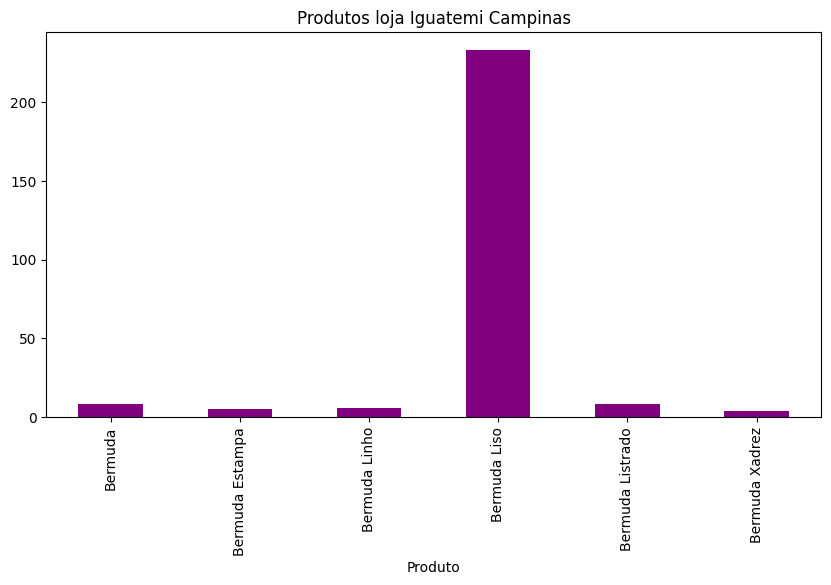

In [21]:
tabela_final.plot(kind='bar' , title = 'Produtos loja Iguatemi Campinas' , figsize=(10,5) , color= 'purple')
